In [22]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import openmc

In [23]:
def load_parameters(filename='parametri.txt'):
    """
    Legge i parametri dal file txt e li restituisce come un dizionario.
    """
    params = {}
    # Forniamo np al contesto di esecuzione per gestire np.sqrt()
    context = {'np': np} 
    
    with open(filename, 'r') as f:
        code = f.read()
        exec(code, context, params)
    
    # Rimuoviamo 'np' e altri built-in dal dizionario finale
    return {k: v for k, v in params.items() if not k.startswith('__') and k != 'np'}


index = 1  # Sostituisci con l'indice desiderato

p = load_parameters('../parametri_' + str(index) + '.txt')


# --- Parametri Geometrici ---
R_CORE    = p['R_CORE']
REF_SIDE  = p['REF_SIDE']
REF_BOT   = p['REF_BOT']
H_CORE    = p['H_CORE']

# --- Parametri Logici ---
R_PIPE    = p['R_PIPE']

# --- Parametri Pin/Lattice ---
R_FUEL    = p['R_FUEL']
CLAD_THICK= p['CLAD_THICK']
R_WATER_THICK = p['R_WATER_THICK']
R_PIN     = p['R_PIN']
PITCH     = p['PITCH']

# --- Parametri Target ---
R_TARGET  = p['R_TARGET']
H_TARGET  = p['H_TARGET']
P_TARGET  = p['P_TARGET']

# --- Sorgente e Simulazione ---
S             = p['S']

bin_ris       = p['bin_ris']

batches       = p['batches_fix']
particles     = p['particles_fix']

arricchimento = p['arricchimento']
mix = p['mix_acqua']
pressione_funzionamento = p['Pressione_funzionamento']

T_water_HZP = p['T_water_HZP']
T_fuel_HFP = p['T_fuel_HFP']
T_fuel_HZP = p['T_fuel_HZP']

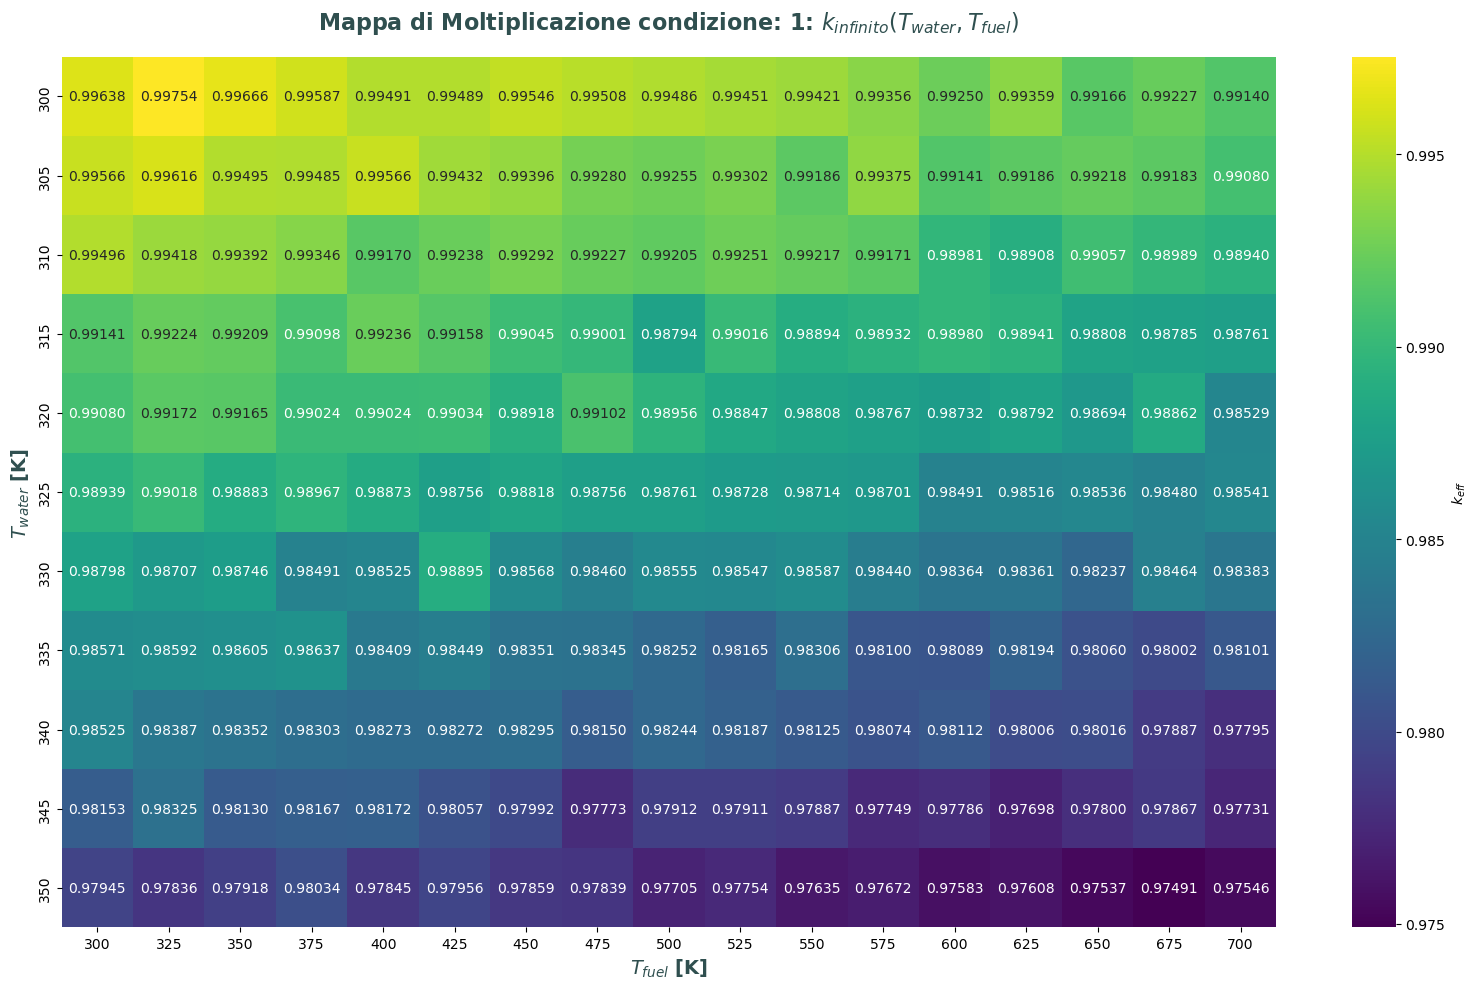

In [24]:
# 1. Parsing robusto del file di output
data = []
data_4_fact = []

path_2 = "output_parametri_" + str(index) + "/result.txt"

with open(path_2, "r") as f:
    for line in f:
        parts = line.strip().split()
        # Isolamento delle righe contenenti le 4 grandezze fisiche
        if len(parts) == 10:
            try:
                t_w = float(parts[0])
                t_f = float(parts[1])
                k = float(parts[2])
                err = float(parts[3])
                epsilon = float(parts[4])
                p = float(parts[5])
                f = float(parts[6])
                eta = float(parts[7])
                Leakage_Fraction = float(parts[8])
                k_inf_leakage = float(parts[9])
                data_4_fact.append([int(t_w), int(t_f), k_inf_leakage])
                data.append([int(t_w), int(t_f), k,err])
            except ValueError:
                continue

df = pd.DataFrame(data_4_fact, columns=['T_water', 'T_fuel', 'k_inf_leakage'])


# 2. Vettorizzazione 2D per la heatmap
heatmap_data = df.pivot(index='T_water', columns='T_fuel', values='k_inf_leakage')

# 3. Setup del plot (Standard Layout)
fig, ax = plt.subplots(figsize=(16, 10))

# Mappatura termica
sns.heatmap(heatmap_data, annot=True, fmt=".5f", cmap="viridis", ax=ax,
            cbar_kws={'label': '$k_{eff}$'})

# Formattazione Titolo e Labels
ax.set_title("Mappa di Moltiplicazione condizione: " + str(index) + ": $k_{infinito}(T_{water}, T_{fuel})$", fontsize=16, fontweight='bold', color='#2F4F4F', pad=20)
ax.set_xlabel("$T_{fuel}$ [K]", fontsize=14, fontweight='bold', color='#2F4F4F')
ax.set_ylabel("$T_{water}$ [K]", fontsize=14, fontweight='bold', color='#2F4F4F')

plt.tight_layout()
plt.show()

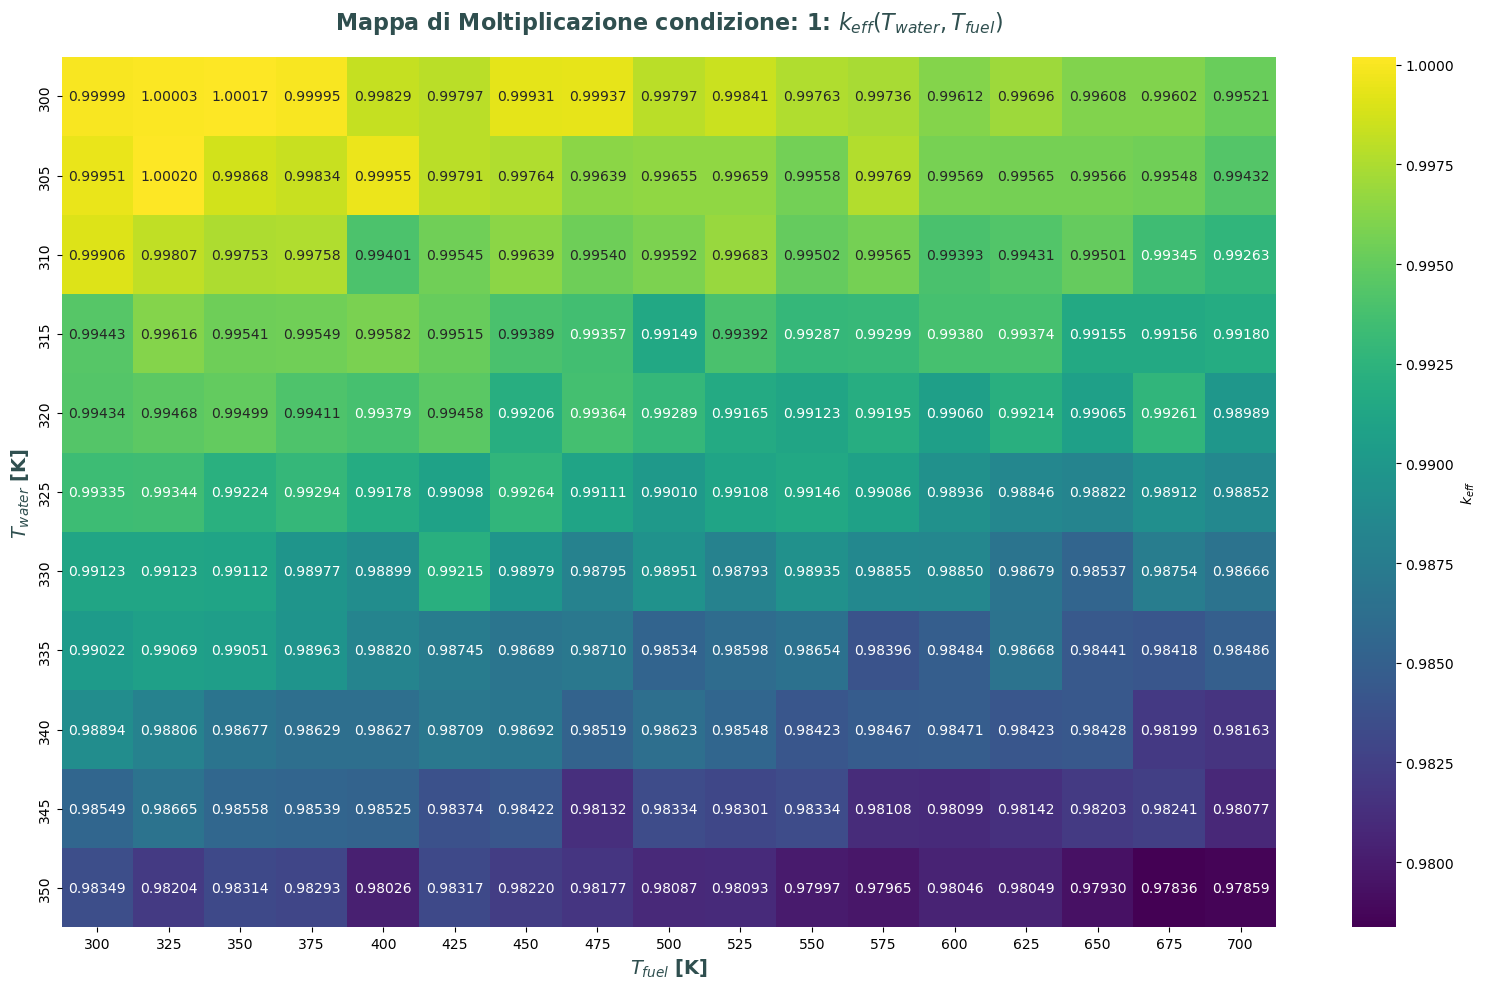

In [25]:
df = pd.DataFrame(data, columns=['T_water', 'T_fuel', 'k_eff', 'std_dev'])

# 2. Vettorizzazione 2D per la heatmap
heatmap_data = df.pivot(index='T_water', columns='T_fuel', values='k_eff')

# 3. Setup del plot (Standard Layout)
fig, ax = plt.subplots(figsize=(16, 10))

# Mappatura termica
sns.heatmap(heatmap_data, annot=True, fmt=".5f", cmap="viridis", ax=ax,
            cbar_kws={'label': '$k_{eff}$'})

# Formattazione Titolo e Labels
ax.set_title("Mappa di Moltiplicazione condizione: " + str(index) + ": $k_{eff}(T_{water}, T_{fuel})$", fontsize=16, fontweight='bold', color='#2F4F4F', pad=20)
ax.set_xlabel("$T_{fuel}$ [K]", fontsize=14, fontweight='bold', color='#2F4F4F')
ax.set_ylabel("$T_{water}$ [K]", fontsize=14, fontweight='bold', color='#2F4F4F')

plt.tight_layout()
plt.show()

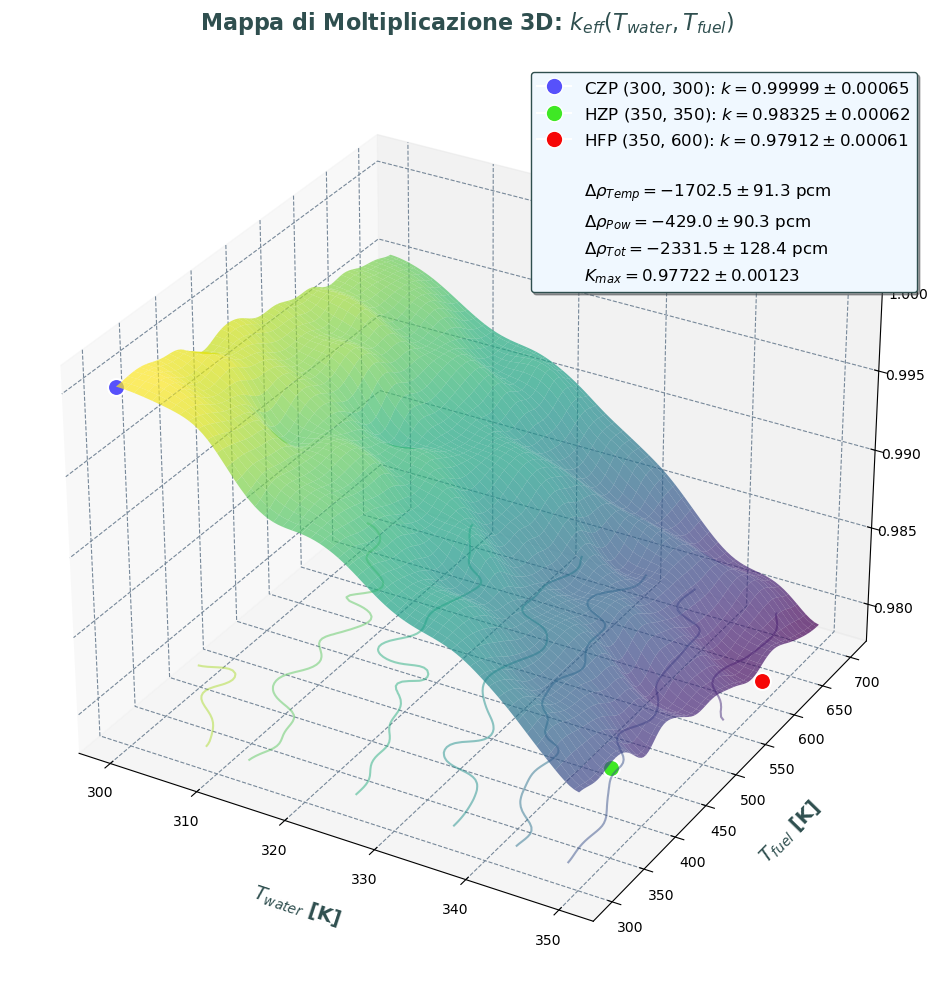

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata
from scipy.ndimage import gaussian_filter
from matplotlib.lines import Line2D

# --- 1. DEFINIZIONE FUNZIONI ---
def calc_reactivity_defect(k1, std1, k2, std2):
    """Calcola il delta_rho in pcm e propaga l'errore statistico."""
    delta_rho = ((k2 - k1) / (k1 * k2)) * 1e5
    err_rho = np.sqrt((std1**2 / k1**4) + (std2**2 / k2**4)) * 1e5
    return delta_rho, err_rho

def get_k_state(df, tw, tf):
    """Recupera k_eff e std_dev per una data coppia di temperature."""
    row = df[(df['T_water'] == tw) & (df['T_fuel'] == tf)]
    if not row.empty:
        return row['k_eff'].values[0], row['std_dev'].values[0]
    else:
        raise ValueError(f"Stato (Tw={tw}K, Tf={tf}K) non trovato nei dati.")

# --- 2. ESTRAZIONE DATI E CALCOLI FISICI ---
T_water_czp, T_fuel_czp = 300.0, 300.0

'''k_czp , std_czp = get_k_state(df, T_water_czp, T_fuel_czp)
k_hzp, std_hzp = get_k_state(df, T_water_HZP, T_fuel_HZP)
k_hfp, std_hfp = get_k_state(df, T_water_HZP, T_fuel_HFP)'''

k_czp , std_czp = 0.99999    ,  0.00065     
k_hzp, std_hzp = 0.98325   ,   0.00062     
k_hfp, std_hfp = 0.97912   ,   0.00061 

rho_temp, err_temp = calc_reactivity_defect(k_czp, std_czp, k_hzp, std_hzp)
rho_pow, err_pow = calc_reactivity_defect(k_hzp, std_hzp, k_hfp, std_hfp)

ignorancy = -200.0 
rho_tot = rho_temp + rho_pow + ignorancy
err_tot = np.sqrt(err_temp**2 + err_pow**2)

rho_max = rho_tot / 1e5
k_max = 1 / (1 - rho_max)
sigma_k = (err_tot / 1e5) * (k_max**2)

# --- 3. PREPARAZIONE DATI PER IL PLOT 3D ---
y = df['T_fuel'].values
x = df['T_water'].values
z = df['k_eff'].values

grid_x, grid_y = np.mgrid[min(x):max(x):100j, min(y):max(y):100j]
grid_z = griddata((x, y), z, (grid_x, grid_y), method='cubic')

nan_mask = np.isnan(grid_z)
grid_z_filled = np.nan_to_num(grid_z, nan=np.nanmean(grid_z))
grid_z = gaussian_filter(grid_z_filled, sigma=3) 
grid_z[nan_mask] = np.nan

# --- 4. CREAZIONE E FORMATTAZIONE DEL PLOT ---
# Unificazione stile: figsize=(16, 10)
fig = plt.figure(figsize=(16, 10))
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(grid_x, grid_y, grid_z, cmap="viridis", edgecolor='none', alpha=0.7)
ax.contour(grid_x, grid_y, grid_z, zdir='z', offset=np.nanmin(grid_z), cmap="viridis", alpha=0.5)

# Punti operativi con bordi per risalto
ax.scatter(T_water_czp, T_fuel_czp, k_czp, color="#5751FB", s=150, edgecolors='w', linewidth=1.5, zorder=5)
ax.scatter(T_water_HZP, T_fuel_HZP, k_hzp, color="#3FE825", s=150, edgecolors='w', linewidth=1.5, zorder=5)
ax.scatter(T_water_HZP, T_fuel_HFP, k_hfp, color="#F60707", s=150, edgecolors='w', linewidth=1.5, zorder=5)

# --- 5. LEGENDA AVANZATA ---
# Creazione dei pallini colorati con incertezze e riga vuota di separazione
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label=rf'CZP (300, 300): $k = {k_czp:.5f} \pm {std_czp:.5f}$',
           markerfacecolor='#5751FB', markersize=12),
    Line2D([0], [0], marker='o', color='w', label=rf'HZP ({T_water_HZP:.0f}, {T_fuel_HZP:.0f}): $k = {k_hzp:.5f} \pm {std_hzp:.5f}$',
           markerfacecolor='#3FE825', markersize=12),
    Line2D([0], [0], marker='o', color='w', label=rf'HFP ({T_water_HZP:.0f}, {T_fuel_HFP:.0f}): $k = {k_hfp:.5f} \pm {std_hfp:.5f}$',
           markerfacecolor='#F60707', markersize=12),
    
    # Riga di spazio vuota
    Line2D([0], [0], color='none', label=' '),
    
    Line2D([0], [0], color='none', label=rf'$\Delta\rho_{{Temp}} = {rho_temp:.1f} \pm {err_temp:.1f}$ pcm'),
    Line2D([0], [0], color='none', label=rf'$\Delta\rho_{{Pow}} = {rho_pow:.1f} \pm {err_pow:.1f}$ pcm'),
    Line2D([0], [0], color='none', label=rf'$\Delta\rho_{{Tot}} = {rho_tot:.1f} \pm {err_tot:.1f}$ pcm'),
    Line2D([0], [0], color='none', label=rf'$K_{{max}} = {k_max:.5f} \pm {sigma_k:.5f}$')
]

# Formattazione Assi e Titoli (Stile Unificato)
ax.set_title(rf"Mappa di Moltiplicazione 3D: $k_{{eff}}(T_{{water}}, T_{{fuel}})$", 
             fontsize=16, fontweight='bold', color='#2F4F4F', pad=25)
ax.set_xlabel(r"$T_{water}$ [K]", fontsize=14, fontweight='bold', color='#2F4F4F', labelpad=15)
ax.set_ylabel(r"$T_{fuel}$ [K]", fontsize=14, fontweight='bold', color='#2F4F4F', labelpad=15)
ax.set_zlabel(r"$k_{eff}$", fontsize=14, fontweight='bold', color='#2F4F4F', labelpad=15)

# Impostazioni Griglia (Stile Unificato)
for axis in [ax.xaxis, ax.yaxis, ax.zaxis]:
    axis._axinfo["grid"].update({"color": "#778899", "linestyle": "--", "alpha": 0.6})

# Legenda (Stile Unificato)
ax.legend(handles=legend_elements, loc='upper right', frameon=True, 
          shadow=True, fontsize=12, facecolor='#F0F8FF', edgecolor='#2F4F4F')

plt.tight_layout()
plt.show()

T_water = 300 K | m = -1.2017e-05 +/- 1.1485e-06 | q = 1.0041e+00 +/- 5.8116e-04
T_water = 305 K | m = -1.2263e-05 +/- 1.3925e-06 | q = 1.0032e+00 +/- 7.0970e-04
T_water = 310 K | m = -1.0518e-05 +/- 2.1663e-06 | q = 1.0008e+00 +/- 1.1283e-03
T_water = 315 K | m = -1.0178e-05 +/- 1.7292e-06 | q = 9.9882e-01 +/- 8.8472e-04
T_water = 320 K | m = -1.0827e-05 +/- 1.6657e-06 | q = 9.9812e-01 +/- 8.7469e-04
T_water = 325 K | m = -1.2332e-05 +/- 1.3868e-06 | q = 9.9706e-01 +/- 7.0210e-04
T_water = 330 K | m = -1.2478e-05 +/- 2.0113e-06 | q = 9.9519e-01 +/- 1.0340e-03
T_water = 335 K | m = -1.6487e-05 +/- 2.0943e-06 | q = 9.9509e-01 +/- 1.0581e-03
T_water = 340 K | m = -1.4158e-05 +/- 1.4757e-06 | q = 9.9255e-01 +/- 7.6440e-04
T_water = 345 K | m = -1.2990e-05 +/- 1.8007e-06 | q = 9.8981e-01 +/- 9.1886e-04
T_water = 350 K | m = -1.1324e-05 +/- 1.5824e-06 | q = 9.8671e-01 +/- 8.1357e-04


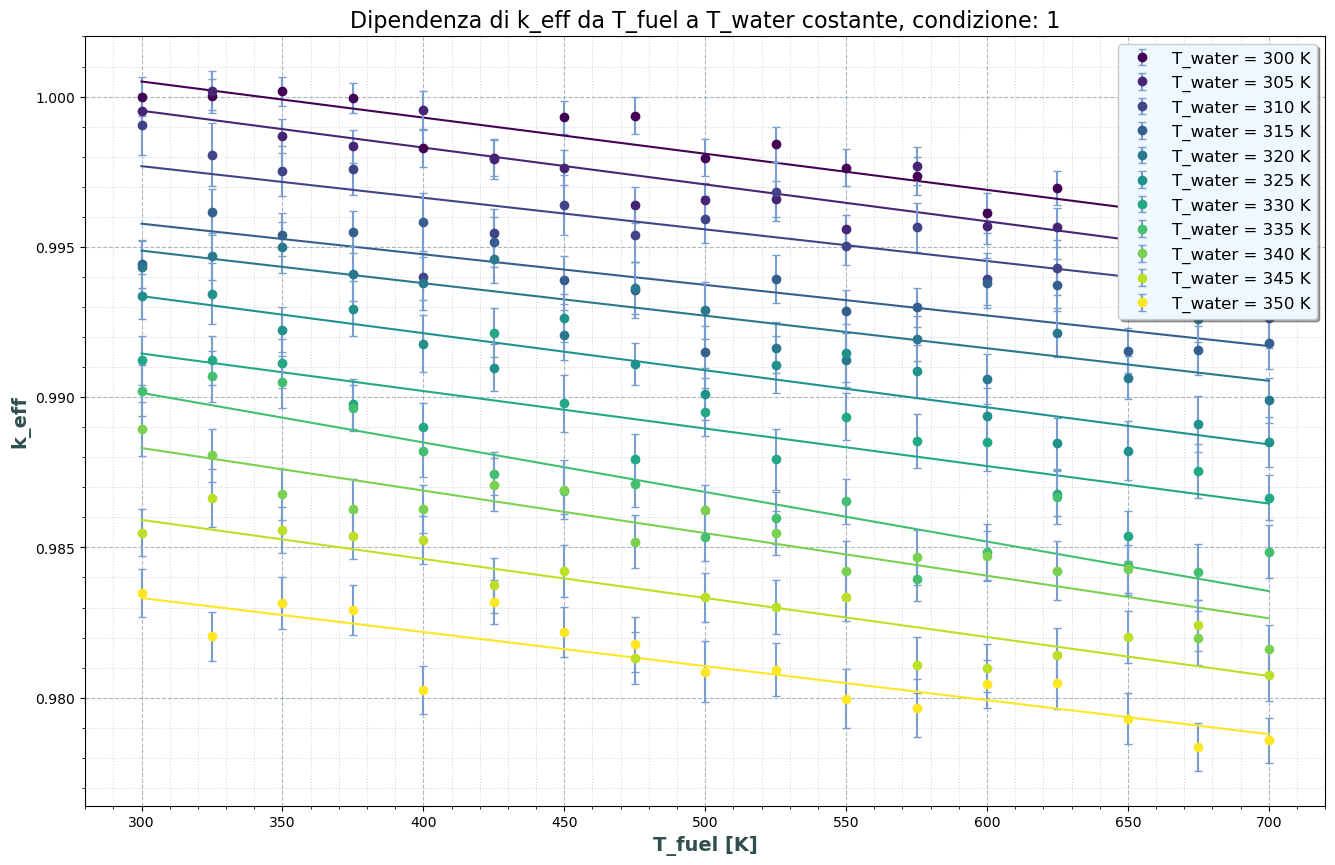

In [27]:
plt.figure(figsize=(16, 10))
t_waters = df['T_water'].unique()
colori_tw = plt.cm.viridis(np.linspace(0, 1, len(t_waters)))

m_values = []
err_m_values = []

for i, tw in enumerate(t_waters):
    df_sub = df[df['T_water'] == tw]
    x = df_sub['T_fuel']
    y = df_sub['k_eff']
    yerr = df_sub['std_dev']

    # Fit lineare pesato: y = m*x + q
    # Usiamo w = 1/yerr (np.polyfit richiede i pesi come 1/sigma)
    p, cov = np.polyfit(x, y, 1, w=1/yerr, cov=True)
    m, q = p
    err_m, err_q = np.sqrt(np.diag(cov))

    # Salvataggio dei coefficienti
    m_values.append(m)
    err_m_values.append(err_m)

    # Stampa dei parametri a schermo
    print(f"T_water = {tw:.0f} K | m = {m:.4e} +/- {err_m:.4e} | q = {q:.4e} +/- {err_q:.4e}")

    # Plot dei punti con barre d'errore (marker uniformati al colore della retta)
    plt.errorbar(x, y, yerr=yerr,
                 fmt='o', color=colori_tw[i],
                 markerfacecolor=colori_tw[i], markeredgecolor=colori_tw[i],
                 ecolor='#789DD1', capsize=3,
                 label=f'T_water = {int(tw)} K')

    # Plot della retta di fit
    plt.plot(x, np.polyval(p, x), '-', color=colori_tw[i])

# Spostato fuori dal loop for per ottimizzazione
m_array = np.array(m_values)
err_m_array = np.array(err_m_values)

plt.title('Dipendenza di k_eff da T_fuel a T_water costante, condizione: ' + str(index), fontsize=16)
plt.xlabel('T_fuel [K]', fontsize=14, fontweight='bold', color='#2F4F4F')
plt.ylabel('k_eff', fontsize=14, fontweight='bold', color='#2F4F4F')

plt.minorticks_on()
plt.grid(True, which='major', linestyle='--', alpha=0.6, color='#778899')
plt.grid(True, which='minor', linestyle=':', alpha=0.3, color='#778899')
plt.legend(loc='upper right', frameon=True, shadow=True, fontsize=12, facecolor='#F0F8FF')

plt.show()

T_fuel = 300 K | m = -3.2813e-04 +/- 1.5824e-06 | q = 1.0994e+00 +/- 8.1357e-04
T_fuel = 325 K | m = -3.4285e-04 +/- 1.5824e-06 | q = 1.1043e+00 +/- 8.1357e-04
T_fuel = 350 K | m = -3.3364e-04 +/- 1.5824e-06 | q = 1.1008e+00 +/- 8.1357e-04
T_fuel = 375 K | m = -3.3969e-04 +/- 1.5824e-06 | q = 1.1024e+00 +/- 8.1357e-04
T_fuel = 400 K | m = -3.4656e-04 +/- 1.5824e-06 | q = 1.1037e+00 +/- 8.1357e-04
T_fuel = 425 K | m = -3.1562e-04 +/- 1.5824e-06 | q = 1.0940e+00 +/- 8.1357e-04
T_fuel = 450 K | m = -3.3438e-04 +/- 1.5824e-06 | q = 1.0998e+00 +/- 8.1357e-04
T_fuel = 475 K | m = -3.5916e-04 +/- 1.5824e-06 | q = 1.1070e+00 +/- 8.1357e-04
T_fuel = 500 K | m = -3.3289e-04 +/- 1.5824e-06 | q = 1.0982e+00 +/- 8.1357e-04
T_fuel = 525 K | m = -3.5522e-04 +/- 1.5824e-06 | q = 1.1056e+00 +/- 8.1357e-04
T_fuel = 550 K | m = -3.3485e-04 +/- 1.5824e-06 | q = 1.0986e+00 +/- 8.1357e-04
T_fuel = 575 K | m = -3.8071e-04 +/- 1.5824e-06 | q = 1.1132e+00 +/- 8.1357e-04
T_fuel = 600 K | m = -3.3596e-04 +/- 1.5

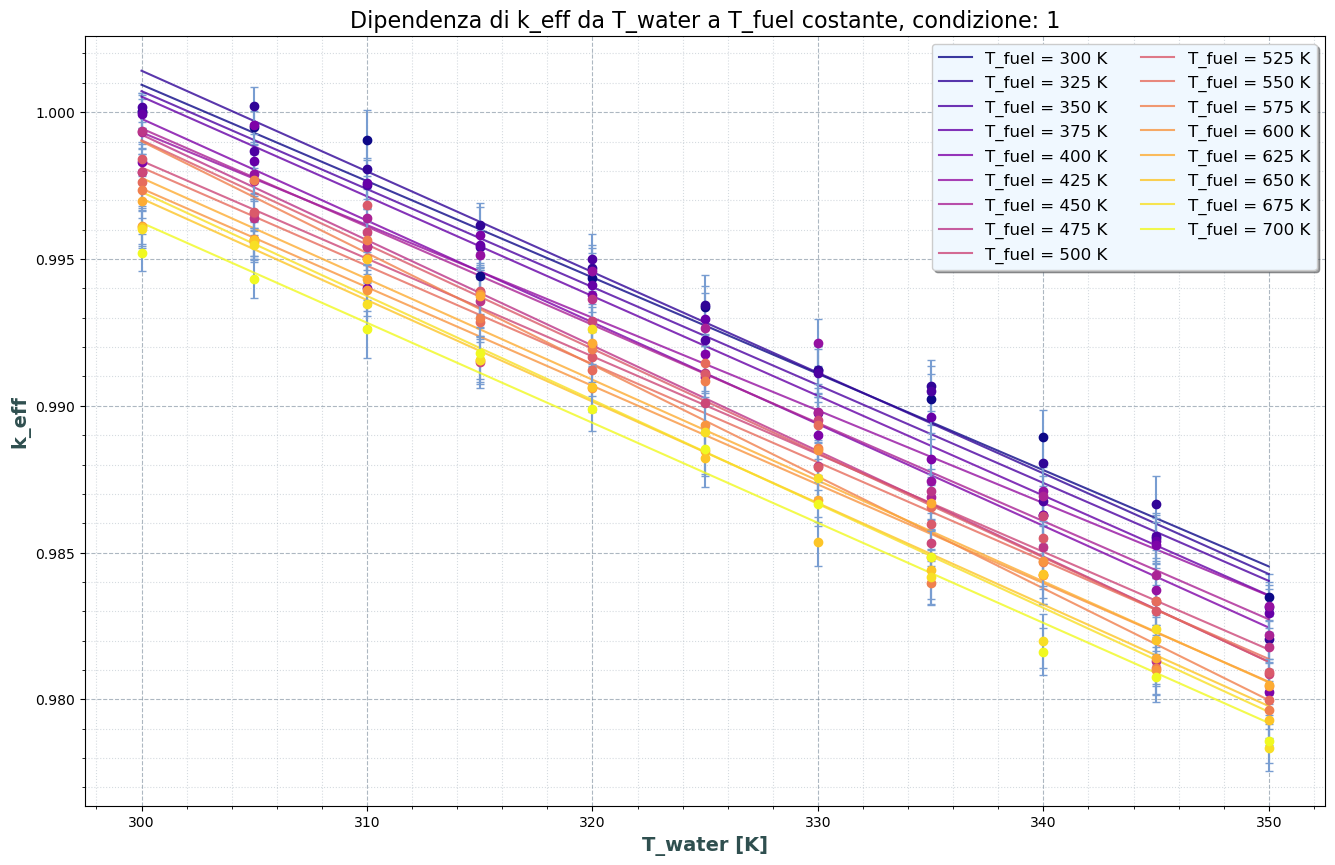

In [28]:

plt.figure(figsize=(16, 10))
t_fuels = df['T_fuel'].unique()
colori_tf = plt.cm.plasma(np.linspace(0, 1, len(t_fuels)))

m_values = []
err_m_values = []

for i, tf in enumerate(t_fuels):
    df_sub = df[df['T_fuel'] == tf]
    x = df_sub['T_water']
    y = df_sub['k_eff']
    
    # Dati sperimentali: punti non collegati
    plt.errorbar(x, y, yerr=df_sub['std_dev'],
                 fmt='o', color=colori_tf[i],
                 markerfacecolor=colori_tf[i], markeredgecolor=colori_tf[i],
                 ecolor='#789DD1', capsize=3)
    
    # Fit lineare: retta dello stesso colore
    m, q = np.polyfit(x, y, 1)
    x_fit = np.linspace(x.min(), x.max(), 100)
    plt.plot(x_fit, m * x_fit + q, '-', color=colori_tf[i], alpha=0.8,
             label=f'T_fuel = {int(tf)} K')
    
    # Salvataggio dei coefficienti
    m_values.append(m)
    err_m_values.append(err_m)

    # Stampa dei parametri a schermo
    print(f"T_fuel = {int(tf)} K | m = {m:.4e} +/- {err_m:.4e} | q = {q:.4e} +/- {err_q:.4e}")


plt.title('Dipendenza di k_eff da T_water a T_fuel costante, condizione: ' + str(index), fontsize=16)
plt.xlabel('T_water [K]', fontsize=14, fontweight='bold', color='#2F4F4F')
plt.ylabel('k_eff', fontsize=14, fontweight='bold', color='#2F4F4F')

plt.minorticks_on()
plt.grid(True, which='major', linestyle='--', alpha=0.6, color='#778899')
plt.grid(True, which='minor', linestyle=':', alpha=0.3, color='#778899')
plt.legend(loc='upper right', frameon=True, shadow=True, fontsize=12, facecolor='#F0F8FF', ncol=2)

plt.show()

- Assumo che il reattore spento stia a 300 K sia in fuel che in acqua Cold Zero Power (CZP)

- definisco poi l'Hot Zero Power, cioè T_fuel = T_water ma a valori maggiori, magari 550K, cioè reattore pronto all'uso ma con ancora nessuna potenza prodotta

- infine serve il HFP = hot full power, cioè massima potenza


Per vedere una variazione:
$$\Delta\rho = \rho_2 - \rho_1 = \frac{k_2 - 1}{k_2} - \frac{k_1 - 1}{k_1} = \frac{k_2 - k_1}{k_1 \cdot k_2}$$


1. Temperature Defect (CZP $\rightarrow$ HZP) Nello stato CZP ($300\text{ K}$), il sistema è freddo. 
L'acqua ha la massima densità, offrendo la massima moderazione (spettro neutronico fortemente termico).
Scaldando il sistema allo stato HZP ($550\text{ K}$), la potenza è ancora nulla, quindi l'equilibrio termico impone $T_{fuel} = T_{water}$. 
    1) Il calo di reattività associato (Temperature Defect) è causato da due contributi: Moderator Temperature Coefficient (MTC) [Dominante]: All'aumentare della temperatura, la densità dell'acqua crolla. Questo causa due effetti: 
    - Diminuisce il potere rallentante ($\xi \Sigma_s$), indurendo lo spettro neutronico. Più neutroni vengono assorbiti nelle risonanze epitemiche dell'$^{238}\text{U}$ prima di termalizzare.
    - Aumenta il cammino libero medio neutronico, incrementando le fughe (leakage) verso i bordi del nocciolo.
    
    2) Effetto Doppler Isotermo [Minoritario]: Anche il combustibile si scalda da $300\text{ K}$ a $550\text{ K}$, causando un primo allargamento delle risonanze di assorbimento (Doppler broadening). 

2. Power Defect (HZP $\rightarrow$ HFP) Allo stato HZP, il reattore è critico e alle condizioni nominali di pressione/temperatura del fluido, ma genera $0\text{ W}$.Portando il reattore allo stato HFP (100% potenza nominale), la temperatura del moderatore resta approssimativamente costante ($T_{water} \approx 550\text{ K}$ media), ma per trasferire l'enorme calore generato per fissione nel pellet verso il fluido, si instaura un ripido gradiente termico. La temperatura media del combustibile $T_{fuel}$ schizza a valori elevati (es. $900\text{ K}$).Il calo di reattività associato (Power Defect) è dominato esclusivamente da un fenomeno: Fuel Temperature Coefficient (FTC) o Effetto Doppler Puro: L'aumento drammatico dell'agitazione termica dei nuclei di $^{238}\text{U}$ nel reticolo cristallino dell'$UO_2$ causa un allargamento (broadening) delle sezioni d'urto di cattura risonante. Sebbene l'integrale dell'area sotto la risonanza resti teoricamente costante, l'allargamento abbassa i picchi e allarga le code (riducendo il self-shielding spaziale ed energetico). Di conseguenza, aumenta drasticamente la probabilità che un neutrone venga catturato parassiticamente dall'$^{238}\text{U}$ durante il rallentamento.Il Power Defect rappresenta il feedback negativo vitale per la stabilità e la sicurezza intrinseca del reattore: all'aumentare della potenza, la fisica stessa del nocciolo "spegne" la reazione a catena. Questo valore definisce quanta reattività (es. estraendo le barre di controllo) l'operatore deve inserire per poter effettivamente far salire il reattore da $0$ al $100\%$ di potenza.


- Temperature Defect (Moderatore + Doppler base): Transizione da CZP a HZP.
$$\Delta\rho_{temp}=\frac{k_{HZP}-k_{CZP}}{k_{HZP}\cdot k_{CZP}}\cdot 10^5\quad [pcm]$$

- Power Defect (Effetto Doppler puro): Transizione da HZP a HFP.
$$\Delta\rho_{power}=\frac{k_{HFP}-k_{HZP}}{k_{HFP}\cdot k_{HZP}}\cdot 10^5\quad [pcm]$$


FATTO NEI CODICI SOPRA, UNIFICATO